# **Отраслевой анализ интенсивности внедрения ИИ в Российской Федерации.**

# 29 отраслей, представленных во всех четырёх годах

**Сельское, лесное хозяйство и рыболовство**

01 — Растениеводство и животноводство, охота и предоставление соответствующих услуг.

02 — Лесоводство и лесозаготовки.

03 — Рыболовство и рыбоводство.

**Добывающая промышленность**

06 — Добыча нефти и природного газа.

07 — Добыча металлических руд.

09 — Предоставление услуг в области добычи полезных ископаемых.

**Обрабатывающая промышленность**

16 — Обработка древесины и производство изделий из дерева.

19 — Производство кокса и нефтепродуктов.

20 — Производство химических веществ и химических продуктов.

21 — Производство лекарственных средств и материалов, применяемых в медицинских целях.

22 — Производство резиновых и пластмассовых изделий.

23 — Производство прочей неметаллической минеральной продукции.

24 — Металлургическое производство.

25 — Производство готовых металлических изделий.

26 — Производство компьютеров, электронных и оптических изделий.

27 — Производство электрического оборудования.

28 — Производство машин и оборудования.

29 — Производство автотранспортных средств, прицепов и полуприцепов.

30 — Производство прочих транспортных средств и оборудования.

33 — Ремонт и монтаж машин и оборудования.

**Торговля**

45 — Торговля автотранспортными средствами и мотоциклами и их ремонт.

46 — Оптовая торговля, кроме торговли автотранспортными средствами.

47 — Розничная торговля, кроме торговли автотранспортными средствами.

**Транспорт и логистика**

49 — Деятельность сухопутного и трубопроводного транспорта.

52 — Складское хозяйство и вспомогательная транспортная деятельность.

**Научная и профессиональная деятельность**

71 — Архитектура, инженерно-техническое проектирование, испытания и анализ.

72 — Научные исследования и разработки.

73 — Рекламная деятельность и исследование конъюнктуры рынка.

**Услуги**

78 — Деятельность по трудоустройству и подбору персонала.

# 11 отраслей с неполными данными

**ОКВЭД	Отрасль	Имеющиеся годы**

05	**Добыча угля**	2021, 2022

08	**Добыча прочих полезных ископаемых**	2021, 2024

17	**Производство бумаги и бумажных изделий**	2021, 2024

18	**Полиграфическая деятельность и копирование носителей**	2021–2023

41	**Строительство зданий**	2021–2023

42	**Строительство инженерных сооружений**	2021–2023

43	**Специализированные строительные работы**	2021–2023

50	**Водный транспорт**	2021, 2022

51	**Воздушный и космический транспорт	только** 2023

53	**Почтовая связь и курьерская деятельность**	только 2021

77	**Аренда и лизинг** 2021, 2022, 2024

В анализе используются три связанные выборки:

1. **df_all** - все доступные наблюдения: 40 отраслей и 141 наблюдение.  
   Используется для описательной статистики, проверки качества данных и анализа покрытия по годам.

2. **df_complete** - только отрасли, представленные во всех годах 2021–2024.  
   Используется для сопоставимой динамики, расчёта CAGR, кластеризации и PCA.

3. **df_ml_all** - все корректные последовательные пары наблюдений.  
   Здесь могут использоваться и отрасли с неполным временным рядом, но только если для них имеются два соседних года. Пропущенные годы не интерполируются и не заменяются нулями.


Данные — панель **ОКВЭД × 2021–2024** (4 года) с показателями:

| Признак | Описание |
|---|---|
| **VDS_s** | ВДС отрасли |
| **ITcosts_s** | затраты на ИТ |
| **skvozcosts_s** | доля «сквозных» цифровых технологий в ИТ-затратах (ИИ, большие данные и т.п.) |
| **trainingcosts_s** | доля затрат на обучение в ИТ-затратах |

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.stats import spearmanr

In [ ]:
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)

plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["font.size"] = 10
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

EXPECTED_YEARS = [2021, 2022, 2023, 2024]

SECTOR_RESULTS_DIR = Path("/content/Результаты_отраслевого_анализа")
FIGURES_DIR = SECTOR_RESULTS_DIR / "Графики"
TABLES_DIR = SECTOR_RESULTS_DIR / "Таблицы"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Папка результатов:", SECTOR_RESULTS_DIR)

Папка результатов: /content/Результаты_отраслевого_анализа


## 1. Загрузка и очистка данных

In [ ]:
FILE_PATH = "/content/Отраслевой_анализ_РФ.xlsx"

cols = [
    "sector", "okved2", "year", "VDS_s",
    "ITcosts_s", "skvozcosts_s", "trainingcosts_s"
]

df = pd.read_excel(FILE_PATH, usecols=cols)

# Приводим названия отраслей и коды ОКВЭД к единому виду
df["sector"] = df["sector"].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
df["okved2"] = pd.to_numeric(df["okved2"], errors="coerce").astype("Int64").astype(str).str.zfill(2)

# Преобразуем показатели в числовой формат
num_cols = ["year", "VDS_s", "ITcosts_s", "skvozcosts_s", "trainingcosts_s"]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

# Удаляем строки с пропусками и оставляем нужный период
df = df.dropna(subset=cols)
df["year"] = df["year"].astype(int)
df = df[df["year"].isin(EXPECTED_YEARS)]

# Если доли записаны в процентах, переводим их в значения от 0 до 1
share_cols = ["skvozcosts_s", "trainingcosts_s"]

for col in share_cols:
    if df[col].max() > 1:
        df[col] = df[col] / 100

# Оставляем только корректные наблюдения
df = df[
    (df["VDS_s"] > 0) &
    (df["ITcosts_s"] >= 0) &
    df["skvozcosts_s"].between(0, 1) &
    df["trainingcosts_s"].between(0, 1)
].copy()

# Проверяем, нет ли повторов одной отрасли в одном году
duplicates = df.duplicated(["okved2", "year"], keep=False)

if duplicates.any():
    display(df.loc[duplicates, ["okved2", "sector", "year"]])
    raise ValueError("Есть повторяющиеся сочетания ОКВЭД и года.")

df = df.sort_values(["okved2", "year"]).reset_index(drop=True)

print("Наблюдений:", len(df))
print("Отраслей:", df["okved2"].nunique())
print("Период:", df["year"].min(), "–", df["year"].max())

display(df.head())

Наблюдений: 141
Отраслей: 40
Период: 2021 – 2024


,sector,okved2,year,VDS_s,ITcosts_s,skvozcosts_s,trainingcosts_s
0,"Растениеводство и животноводство, охота и пред...",01,2021,3.292837e+06,5258.570126,0.010604,0.001869
1,"Растениеводство и животноводство, охота и пред...",01,2022,3.097084e+06,4162.472168,0.001408,0.003957
2,"Растениеводство и животноводство, охота и пред...",01,2023,2.652659e+06,4253.661578,0.002881,0.001838
3,"Растениеводство и животноводство, охота и пред...",01,2024,2.480166e+06,4510.031616,0.001004,0.001221
4,Лесоводство и лесозаготовки,02,2021,1.774761e+05,1454.999921,0.000273,0.000876


## 2. Проверка полноты панели

In [ ]:
expected_years = tuple(EXPECTED_YEARS)

coverage = df.groupby(["okved2", "sector"])["year"].agg(
    years_count="nunique",
    available_years_tuple=lambda x: tuple(sorted(x.unique()))
).reset_index()

coverage["available_years"] = coverage["available_years_tuple"].map(
    lambda x: ", ".join(map(str, x))
)
coverage["complete_panel"] = coverage["available_years_tuple"].map(
    expected_years.__eq__
)
coverage["data_quality_weight"] = coverage["years_count"] / len(expected_years)

print("Отраслей с полным рядом:", coverage["complete_panel"].sum())
print("Отраслей с неполным рядом:", (~coverage["complete_panel"]).sum())

result = coverage.sort_values(
    ["complete_panel", "okved2"],
    ascending=[False, True]
)[
    ["okved2", "sector", "years_count", "available_years",
     "complete_panel", "data_quality_weight"]
].reset_index(drop=True)

display(result)

Отраслей с полным рядом: 29
Отраслей с неполным рядом: 11


,okved2,sector,years_count,available_years,complete_panel,data_quality_weight
0,01,"Растениеводство и животноводство, охота и пред...",4,"2021, 2022, 2023, 2024",True,1.00
1,02,Лесоводство и лесозаготовки,4,"2021, 2022, 2023, 2024",True,1.00
2,03,Рыболовство и рыбоводство,4,"2021, 2022, 2023, 2024",True,1.00
3,06,Добыча нефти и природного газа,4,"2021, 2022, 2023, 2024",True,1.00
4,07,Добыча металлических руд,4,"2021, 2022, 2023, 2024",True,1.00
5,09,Предоставление услуг в области добычи полезных...,4,"2021, 2022, 2023, 2024",True,1.00
6,16,Обработка древесины и производство изделий из ...,4,"2021, 2022, 2023, 2024",True,1.00
7,19,Производство кокса и нефтепродуктов,4,"2021, 2022, 2023, 2024",True,1.00
8,20,Производство химических веществ и химических п...,4,"2021, 2022, 2023, 2024",True,1.00
9,21,Производство лекарственных средств и материало...,4,"2021, 2022, 2023, 2024",True,1.00


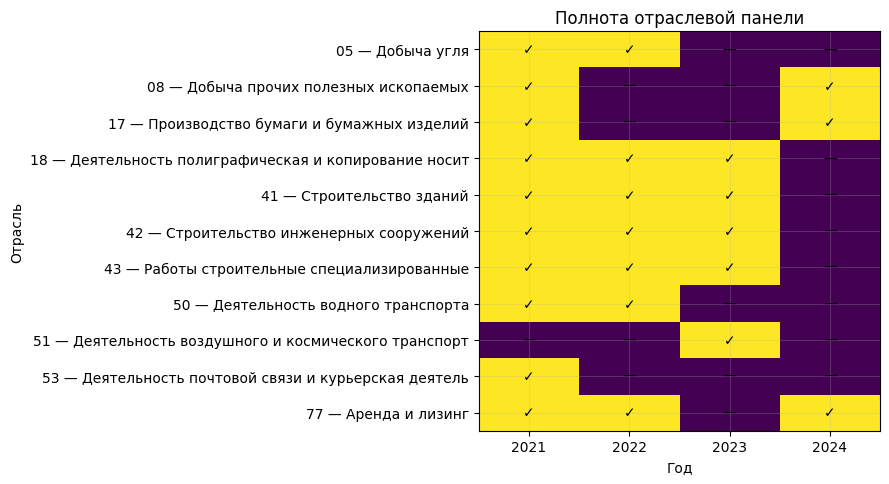

In [ ]:
coverage_matrix = df.assign(observed=1).pivot_table(
    index=["okved2", "sector"],
    columns="year",
    values="observed",
    aggfunc="max",
    fill_value=0
)

coverage_matrix = coverage_matrix.reindex(columns=expected_years, fill_value=0)
coverage_matrix["years_count"] = coverage_matrix.sum(axis=1)

incomplete_matrix = coverage_matrix[coverage_matrix["years_count"] < len(expected_years)]
incomplete_matrix = incomplete_matrix.drop(columns="years_count")

if incomplete_matrix.empty:
    print("Все отрасли имеют полный временной ряд.")
else:
    labels = [f"{okved} — {sector[:48]}" for okved, sector in incomplete_matrix.index]

    fig, ax = plt.subplots(figsize=(9, max(4, len(incomplete_matrix) * 0.45)))
    ax.imshow(incomplete_matrix.to_numpy(), aspect="auto", vmin=0, vmax=1)

    ax.set_xticks(range(len(expected_years)))
    ax.set_xticklabels(expected_years)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)

    for i in range(incomplete_matrix.shape[0]):
        for j in range(incomplete_matrix.shape[1]):
            value = incomplete_matrix.iloc[i, j]
            ax.text(j, i, "✓" if value == 1 else "—", ha="center", va="center")

    ax.set_xlabel("Год")
    ax.set_ylabel("Отрасль")
    ax.set_title("Полнота отраслевой панели")

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "01_полнота_отраслевой_панели.png", dpi=200, bbox_inches="tight")
    plt.show()

## 3. Относительные цифровые показатели

Показатели рассчитываются относительно ВДС, чтобы крупные отрасли не получали преимущество только из-за экономического масштаба.

In [ ]:
df["IT_intensity"] = df["ITcosts_s"] / df["VDS_s"]
df["skvoz_amount"] = df["ITcosts_s"] * df["skvozcosts_s"]
df["training_amount"] = df["ITcosts_s"] * df["trainingcosts_s"]
df["skvoz_intensity"] = df["skvoz_amount"] / df["VDS_s"]
df["training_intensity"] = df["training_amount"] / df["VDS_s"]

indicators = ["IT_intensity", "skvoz_intensity", "training_intensity"]
display(df[indicators].describe().T)

,count,mean,std,min,25%,50%,75%,max
IT_intensity,141.0,0.019667,0.024626,1.139354e-03,0.006660,0.012741,0.022667,0.176749
skvoz_intensity,141.0,0.000159,0.000368,2.318326e-07,0.000006,0.000033,0.000104,0.002446
training_intensity,141.0,0.000131,0.000973,5.956548e-07,0.000005,0.000013,0.000029,0.011482


## 4. Формирование отраслевого профиля

Индекс рассчитывается для всех отраслей. Параметры преобразования и PCA оцениваются только по полной панели, а затем применяются к неполным рядам. Поэтому неполные отрасли получают предварительные оценки и не определяют шкалу индекса.

In [ ]:
profile = df.groupby(["okved2", "sector"], as_index=False).agg(
    VDS_mean=("VDS_s", "mean"),
    IT_intensity_median=("IT_intensity", "median"),
    skvoz_intensity_median=("skvoz_intensity", "median"),
    training_intensity_median=("training_intensity", "median")
)

profile = profile.merge(
    coverage[[
        "okved2", "years_count", "available_years",
        "complete_panel", "data_quality_weight"
    ]],
    on="okved2",
    how="left"
)

profile_features = ["skvoz_intensity_median", "training_intensity_median"]

display(profile.head())

,okved2,sector,VDS_mean,IT_intensity_median,skvoz_intensity_median,training_intensity_median,years_count,available_years,complete_panel,data_quality_weight
0,01,"Растениеводство и животноводство, охота и пред...",2.880687e+06,0.001600,0.000003,2.965887e-06,4,"2021, 2022, 2023, 2024",True,1.0
1,02,Лесоводство и лесозаготовки,1.423143e+05,0.007218,0.000047,1.929127e-05,4,"2021, 2022, 2023, 2024",True,1.0
2,03,Рыболовство и рыбоводство,2.610551e+05,0.003546,0.000002,6.639671e-06,4,"2021, 2022, 2023, 2024",True,1.0
3,05,Добыча угля,1.734594e+06,0.001264,0.000015,8.861143e-07,2,"2021, 2022",False,0.5
4,06,Добыча нефти и природного газа,1.194515e+07,0.002650,0.000002,2.396475e-06,4,"2021, 2022, 2023, 2024",True,1.0


## 5. Индекс отраслевой восприимчивости

Итоговый индекс объединяет два подхода:

- PCA-индекс, веса которого определяются структурой данных;
- индекс равных весов, построенный по процентильным баллам от 0 до 100.

Итоговая оценка рассчитывается как среднее двух индексов.

In [ ]:
complete_mask = profile["complete_panel"].fillna(False)

def reference_score(values, reference):
    reference = np.sort(reference.dropna().unique())
    if len(reference) < 2:
        return pd.Series(50.0, index=values.index)
    return pd.Series(
        np.interp(values, reference, np.linspace(0, 100, len(reference))),
        index=values.index)

features = {
    "skvoz_intensity_median": "skvoz_score",
    "training_intensity_median": "training_score"}

for source, score in features.items():
    profile[score] = reference_score(
        profile[source],
        profile.loc[complete_mask, source])

profile["AI_intensity"] = profile[list(features.values())].mean(axis=1)
profile["rank"] = profile.loc[complete_mask, "AI_intensity"].rank(
    ascending=False, method="min"
).astype("Int64")

result = profile.loc[
    complete_mask,
    ["rank", "okved2", "sector", "skvoz_score", "training_score", "AI_intensity"]
].sort_values("rank").reset_index(drop=True)

display(result.round(2))

,rank,okved2,sector,skvoz_score,training_score,AI_intensity
0,1,72,Научные исследования и разработки,96.43,96.43,96.43
1,2,26,"Производство компьютеров, электронных и оптиче...",89.29,89.29,89.29
2,2,71,Деятельность в области архитектуры и инженерно...,85.71,92.86,89.29
3,4,25,"Производство готовых металлических изделий, кр...",92.86,71.43,82.14
4,5,28,"Производство машин и оборудования, не включенн...",75.00,82.14,78.57
5,6,30,Производство прочих транспортных средств и обо...,60.71,85.71,73.21
6,7,49,Деятельность сухопутного и трубопроводного тра...,67.86,64.29,66.07
7,8,27,Производство электрического оборудования,53.57,78.57,66.07
8,9,73,Деятельность рекламная и исследование конъюнкт...,46.43,75.00,60.71
9,9,19,Производство кокса и нефтепродуктов,100.00,21.43,60.71


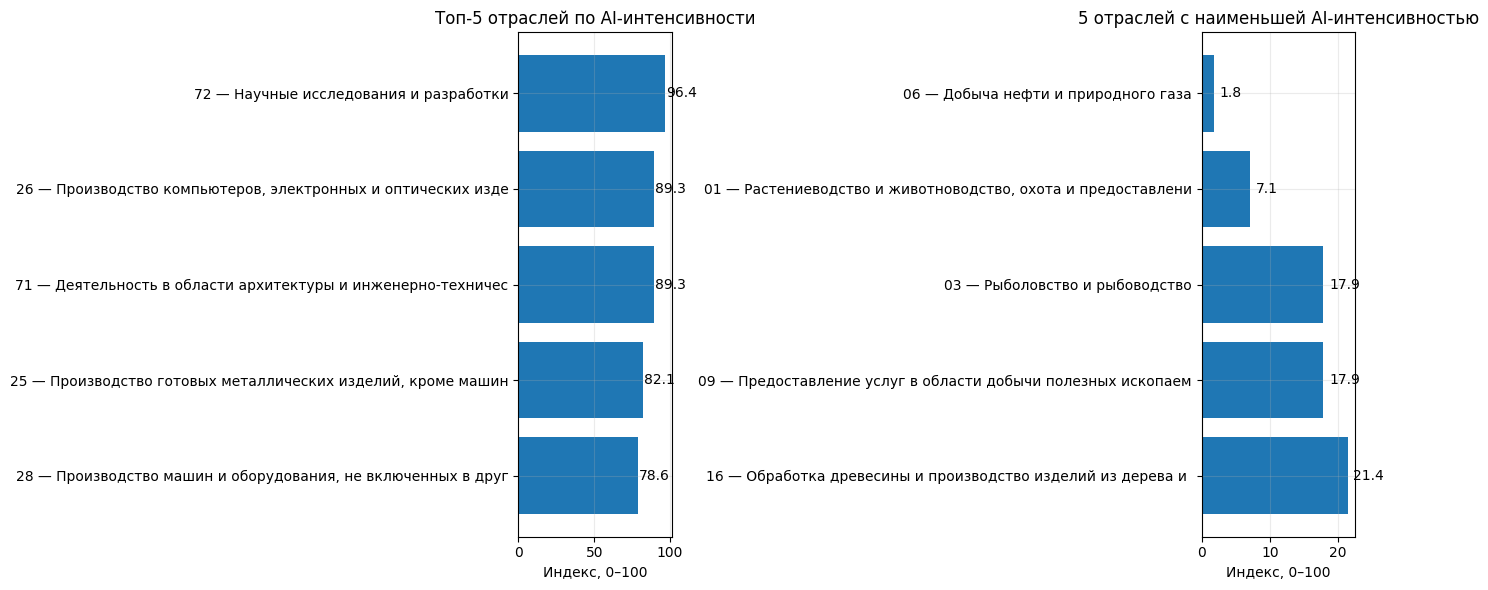

In [ ]:
best_5 = profile[profile["complete_panel"]].nlargest(5, "AI_intensity").copy()
worst_5 = profile[profile["complete_panel"]].nsmallest(5, "AI_intensity").copy()

best_5["label"] = best_5["okved2"] + " — " + best_5["sector"].str[:55]
worst_5["label"] = worst_5["okved2"] + " — " + worst_5["sector"].str[:55]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Лучшие
bars1 = axes[0].barh(best_5["label"], best_5["AI_intensity"])
axes[0].set_title("Топ-5 отраслей по AI-интенсивности")
axes[0].set_xlabel("Индекс, 0–100")
axes[0].invert_yaxis()

for bar, value in zip(bars1, best_5["AI_intensity"]):
    axes[0].text(value + 0.8, bar.get_y() + bar.get_height() / 2, f"{value:.1f}", va="center")

# Худшие
bars2 = axes[1].barh(worst_5["label"], worst_5["AI_intensity"])
axes[1].set_title("5 отраслей с наименьшей AI-интенсивностью")
axes[1].set_xlabel("Индекс, 0–100")
axes[1].invert_yaxis()

for bar, value in zip(bars2, worst_5["AI_intensity"]):
    axes[1].text(value + 0.8, bar.get_y() + bar.get_height() / 2, f"{value:.1f}", va="center")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_лучшие_и_худшие_отрасли.png", dpi=200, bbox_inches="tight")
plt.show()

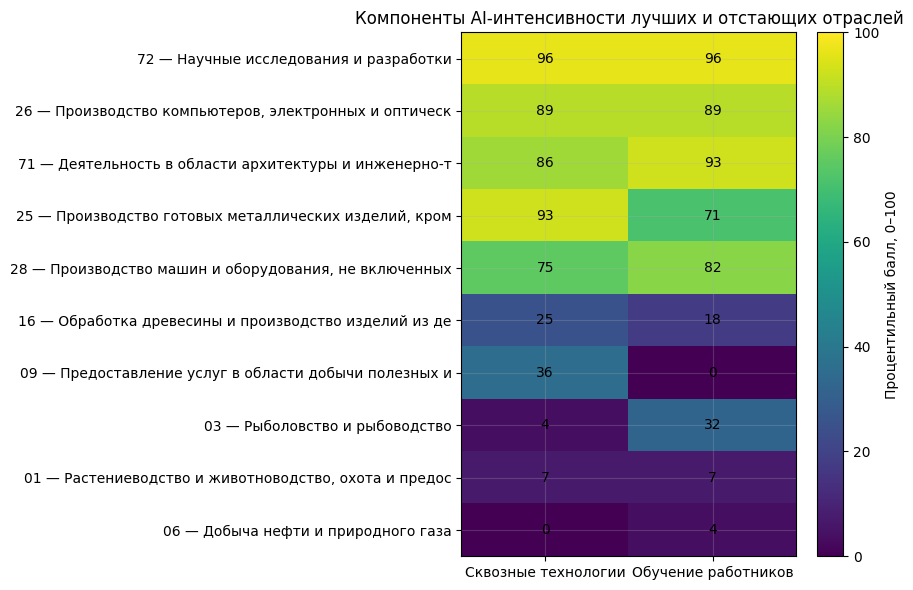

In [ ]:
component_cols = ["skvoz_score", "training_score"]
component_names = ["Сквозные технологии", "Обучение работников"]

complete_profile = profile[profile["complete_panel"]].copy()

heatmap_data = pd.concat([
    complete_profile.nlargest(5, "AI_intensity"),
    complete_profile.nsmallest(5, "AI_intensity")
]).drop_duplicates("okved2")

heatmap_data = heatmap_data.sort_values("AI_intensity", ascending=False)
heatmap_data["label"] = heatmap_data["okved2"] + " — " + heatmap_data["sector"].str[:48]

matrix = heatmap_data[component_cols].to_numpy()

fig, ax = plt.subplots(figsize=(9, 6))
image = ax.imshow(matrix, aspect="auto", vmin=0, vmax=100)

ax.set_xticks(range(len(component_names)))
ax.set_xticklabels(component_names)
ax.set_yticks(range(len(heatmap_data)))
ax.set_yticklabels(heatmap_data["label"])

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(j, i, f"{matrix[i, j]:.0f}", ha="center", va="center")

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Процентильный балл, 0–100")

ax.set_title("Компоненты AI-интенсивности лучших и отстающих отраслей")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "03_компоненты_AI_интенсивности.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

## 6. Экономическая динамика отраслей


$$
CAGR = \left(\frac{X_{\text{последний год}}}{X_{\text{первый год}}}\right)^{\frac{1}{n}} - 1
$$



In [ ]:
def calculate_cagr(group, col):
    group = group.sort_values("year")
    first, last = group.iloc[0], group.iloc[-1]
    years = last["year"] - first["year"]

    if years <= 0 or first[col] <= 0 or last[col] <= 0:
        return np.nan

    return (last[col] / first[col]) ** (1 / years) - 1


rows = []

for (okved2, sector), group in df.groupby(["okved2", "sector"]):
    rows.append({
        "okved2": okved2,
        "sector": sector,
        "VDS_CAGR": calculate_cagr(group, "VDS_s"),
        "IT_CAGR": calculate_cagr(group, "ITcosts_s")
    })

dynamics = pd.DataFrame(rows)
profile = profile.merge(dynamics, on=["okved2", "sector"], how="left")

display(
    profile[["okved2", "sector", "VDS_CAGR", "IT_CAGR"]]
    .sort_values("VDS_CAGR", ascending=False)
    .head(15)
    .style.format({"VDS_CAGR": "{:.2%}", "IT_CAGR": "{:.2%}"})
)

,okved2,sector,VDS_CAGR,IT_CAGR
35,71,"Деятельность в области архитектуры и инженерно-технического проектирования; технических испытаний, исследований и анализа",23.42%,-27.92%
31,50,Деятельность водного транспорта,20.86%,-22.43%
20,28,"Производство машин и оборудования, не включенных в другие группировки",15.78%,4.71%
39,78,Деятельность по трудоустройству и подбору персонала,14.87%,-31.88%
18,26,"Производство компьютеров, электронных и оптических изделий",12.78%,-4.37%
19,27,Производство электрического оборудования,12.55%,11.66%
17,25,"Производство готовых металлических изделий, кроме машин и оборудования",11.70%,-2.08%
3,05,Добыча угля,10.57%,-9.22%
10,18,Деятельность полиграфическая и копирование носителей информации,7.40%,-11.92%
33,52,Складское хозяйство и вспомогательная транспортная деятельность,5.96%,-21.38%


## 7. Матрица типов отраслей

Пороговые значения рассчитываются по медианам отраслей с полным временным рядом. Размер круга отражает средний экономический вес отрасли по ВДС.

In [ ]:
valid = profile["complete_panel"] & profile["VDS_CAGR"].notna()
ai_threshold = profile.loc[valid, "AI_intensity"].median()
growth_threshold = profile.loc[valid, "VDS_CAGR"].median()

high_ai = profile["AI_intensity"] >= ai_threshold
high_growth = profile["VDS_CAGR"] >= growth_threshold

profile["industry_type"] = np.select(
    [
        valid & high_ai & high_growth,
        valid & high_ai & ~high_growth,
        valid & ~high_ai & high_growth,
        valid & ~high_ai & ~high_growth
    ],
    [
        "Цифровые лидеры",
        "Нереализованный цифровой потенциал",
        "Растущие традиционные отрасли",
        "Зона базовой цифровизации"
    ],
    default="Недостаточно данных"
)

matrix_base = profile[valid].copy()

print("Порог AI-интенсивности:", round(ai_threshold, 2))
print("Порог динамики ВДС:", f"{growth_threshold:.2%}")

summary = matrix_base.groupby("industry_type", as_index=False).agg(
    industries=("sector", "count"),
    median_AI=("AI_intensity", "median"),
    median_VDS_CAGR=("VDS_CAGR", "median")
)

display(
    summary.sort_values("median_AI", ascending=False)
    .style.format({"median_AI": "{:.1f}", "median_VDS_CAGR": "{:.2%}"})
)

Порог AI-интенсивности: 48.21
Порог динамики ВДС: -0.81%


,industry_type,industries,median_AI,median_VDS_CAGR
3,Цифровые лидеры,9,78.6,11.70%
1,Нереализованный цифровой потенциал,6,57.1,-9.95%
2,Растущие традиционные отрасли,6,33.9,3.85%
0,Зона базовой цифровизации,8,19.6,-4.41%


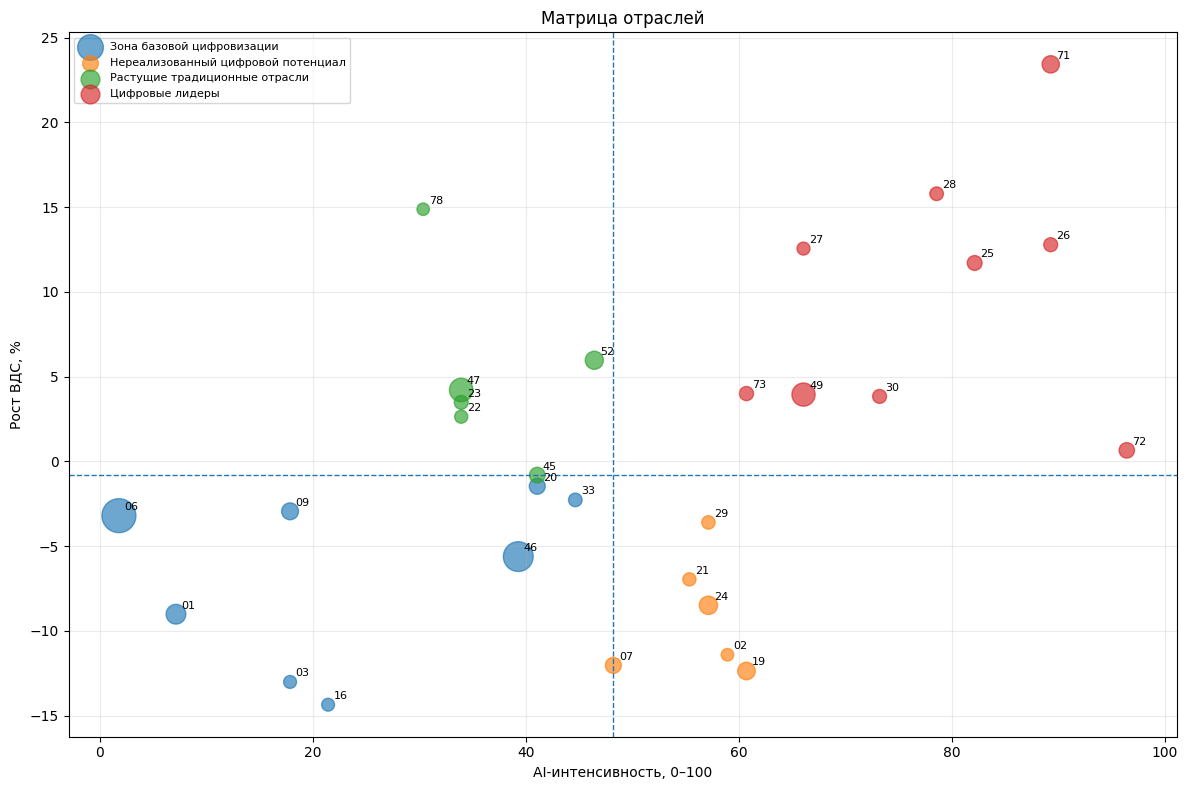

In [ ]:
matrix_plot = matrix_base.copy()

vmin = matrix_plot["VDS_mean"].min()
vmax = matrix_plot["VDS_mean"].max()

if vmax > vmin:
    matrix_plot["bubble_size"] = 80 + 520 * (matrix_plot["VDS_mean"] - vmin) / (vmax - vmin)
else:
    matrix_plot["bubble_size"] = 180

fig, ax = plt.subplots(figsize=(12, 8))

for name, group in matrix_plot.groupby("industry_type"):
    ax.scatter(
        group["AI_intensity"],
        group["VDS_CAGR"] * 100,
        s=group["bubble_size"],
        alpha=0.65,
        label=name
    )

for _, row in matrix_plot.iterrows():
    ax.annotate(
        row["okved2"],
        (row["AI_intensity"], row["VDS_CAGR"] * 100),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

ax.axvline(ai_threshold, linestyle="--", linewidth=1)
ax.axhline(growth_threshold * 100, linestyle="--", linewidth=1)

ax.set_xlabel("AI-интенсивность, 0–100")
ax.set_ylabel("Рост ВДС, %")
ax.set_title("Матрица отраслей")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_матрица_отраслей.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Агрегирование к семи укрупнённым секторам

Подробные ОКВЭД агрегируются до семи секторов, используемых в региональной статистике. Веса определяются средней ВДС отрасли и полнотой её временного ряда. Полученный показатель обозначается как `sector_exposure` и далее используется как отраслевой вход для расчёта региональной AI-экспозиции.

In [ ]:
OKVED_TO_VRP = {
    "01": "сельское_лесное_хозяйство_рыболовство",
    "02": "сельское_лесное_хозяйство_рыболовство",
    "03": "сельское_лесное_хозяйство_рыболовство",
    "05": "добыча_полезных_ископаемых",
    "06": "добыча_полезных_ископаемых",
    "07": "добыча_полезных_ископаемых",
    "08": "добыча_полезных_ископаемых",
    "09": "добыча_полезных_ископаемых",
    "16": "обрабатывающие_производства",
    "17": "обрабатывающие_производства",
    "18": "обрабатывающие_производства",
    "19": "обрабатывающие_производства",
    "20": "обрабатывающие_производства",
    "21": "обрабатывающие_производства",
    "22": "обрабатывающие_производства",
    "23": "обрабатывающие_производства",
    "24": "обрабатывающие_производства",
    "25": "обрабатывающие_производства",
    "26": "обрабатывающие_производства",
    "27": "обрабатывающие_производства",
    "28": "обрабатывающие_производства",
    "29": "обрабатывающие_производства",
    "30": "обрабатывающие_производства",
    "33": "обрабатывающие_производства",
    "41": "строительство",
    "42": "строительство",
    "43": "строительство",
    "45": "торговля_ремонт",
    "46": "торговля_ремонт",
    "47": "торговля_ремонт",
    "49": "транспорт_связь_информация",
    "50": "транспорт_связь_информация",
    "51": "транспорт_связь_информация",
    "52": "транспорт_связь_информация",
    "53": "транспорт_связь_информация",
    "71": "недвижимость_проф_научные_и_адм_услуги",
    "72": "недвижимость_проф_научные_и_адм_услуги",
    "73": "недвижимость_проф_научные_и_адм_услуги",
    "77": "недвижимость_проф_научные_и_адм_услуги",
    "78": "недвижимость_проф_научные_и_адм_услуги"
}

SECTOR_LABELS = {
    "сельское_лесное_хозяйство_рыболовство": "Сельское и лесное хозяйство, рыболовство",
    "добыча_полезных_ископаемых": "Добыча полезных ископаемых",
    "обрабатывающие_производства": "Обрабатывающие производства",
    "строительство": "Строительство",
    "торговля_ремонт": "Торговля и ремонт",
    "транспорт_связь_информация": "Транспорт, связь и информация",
    "недвижимость_проф_научные_и_адм_услуги": "Профессиональные, научные и административные услуги"
}

profile["vrp_sector"] = profile["okved2"].map(OKVED_TO_VRP)

unmapped = profile.loc[
    profile["vrp_sector"].isna(),
    ["okved2", "sector"]
]

if not unmapped.empty:
    display(unmapped)
    raise KeyError("Не все ОКВЭД сопоставлены с укрупнёнными секторами.")

sector_data = profile.dropna(
    subset=["vrp_sector", "AI_intensity", "VDS_mean", "data_quality_weight"]
).copy()

sector_data["weight"] = (
    sector_data["VDS_mean"].clip(lower=0)
    * sector_data["data_quality_weight"].clip(0, 1)
)

sector_data["weighted_AI"] = (
    sector_data["AI_intensity"] * sector_data["weight"]
)

sector_exposure = sector_data.groupby("vrp_sector", as_index=False).agg(
    weighted_AI=("weighted_AI", "sum"),
    total_weight=("weight", "sum"),
    n_okved=("okved2", "nunique"),
    n_complete_okved=("complete_panel", "sum"),
    mean_data_quality=("data_quality_weight", "mean")
)

if (sector_exposure["total_weight"] <= 0).any():
    raise ValueError("Для одного или нескольких секторов сумма весов равна нулю.")

sector_exposure["sector_AI_intensity"] = (
    sector_exposure["weighted_AI"] / sector_exposure["total_weight"]
)

sector_exposure["sector_name"] = (
    sector_exposure["vrp_sector"].map(SECTOR_LABELS)
)

sector_exposure = sector_exposure[[
    "vrp_sector",
    "sector_name",
    "sector_AI_intensity",
    "n_okved",
    "n_complete_okved",
    "mean_data_quality"
]].sort_values(
    "sector_AI_intensity",
    ascending=False
).reset_index(drop=True)

if len(sector_exposure) != 7:
    raise ValueError(
        f"После агрегации получено {len(sector_exposure)} секторов вместо 7."
    )

if sector_exposure["sector_name"].isna().any():
    raise ValueError("Для некоторых секторов отсутствуют названия.")

display(sector_exposure.round(2))

,vrp_sector,sector_name,sector_AI_intensity,n_okved,n_complete_okved,mean_data_quality
0,недвижимость_проф_научные_и_адм_услуги,"Профессиональные, научные и административные у...",78.74,5,4,0.95
1,транспорт_связь_информация,"Транспорт, связь и информация",59.06,5,2,0.60
2,обрабатывающие_производства,Обрабатывающие производства,58.20,16,14,0.95
3,торговля_ремонт,Торговля и ремонт,37.68,3,3,1.00
4,сельское_лесное_хозяйство_рыболовство,"Сельское и лесное хозяйство, рыболовство",10.24,3,3,1.00
5,добыча_полезных_ископаемых,Добыча полезных ископаемых,8.48,5,3,0.80
6,строительство,Строительство,8.15,3,0,0.75


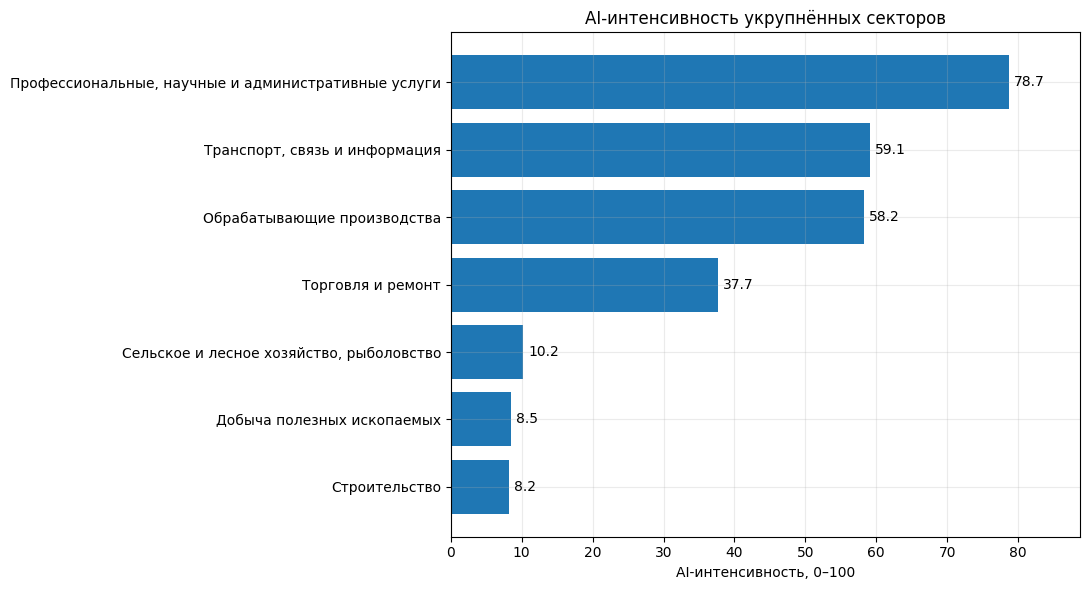

In [ ]:
sector_plot = sector_exposure.sort_values("sector_AI_intensity")

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(sector_plot["sector_name"], sector_plot["sector_AI_intensity"])

for bar, value in zip(bars, sector_plot["sector_AI_intensity"]):
    ax.text(value + 0.7, bar.get_y() + bar.get_height() / 2, f"{value:.1f}", va="center")

ax.set(
    xlabel="AI-интенсивность, 0–100",
    ylabel="",
    title="AI-интенсивность укрупнённых секторов",
    xlim=(0, min(105, sector_plot["sector_AI_intensity"].max() + 10))
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_AI_интенсивность_секторов.png", dpi=200, bbox_inches="tight")
plt.show()

### Внешняя проверка


Spearman ρ = 0.786, p = 0.0362, n = 7


,sector_name,sector_AI_intensity,AIIE_external,rank_internal,rank_external,n_okved,n_complete_okved,mean_data_quality
0,"Профессиональные, научные и административные у...",78.736,0.631,1.0,1.0,5,4,0.950
1,"Транспорт, связь и информация",59.058,0.011,2.0,3.0,5,2,0.600
2,Обрабатывающие производства,58.203,-0.484,3.0,4.0,16,14,0.953
3,Торговля и ремонт,37.682,0.069,4.0,2.0,3,3,1.000
4,"Сельское и лесное хозяйство, рыболовство",10.239,-1.558,5.0,7.0,3,3,1.000
5,Добыча полезных ископаемых,8.480,-0.678,6.0,5.0,5,3,0.800
6,Строительство,8.151,-0.997,7.0,6.0,3,0,0.750


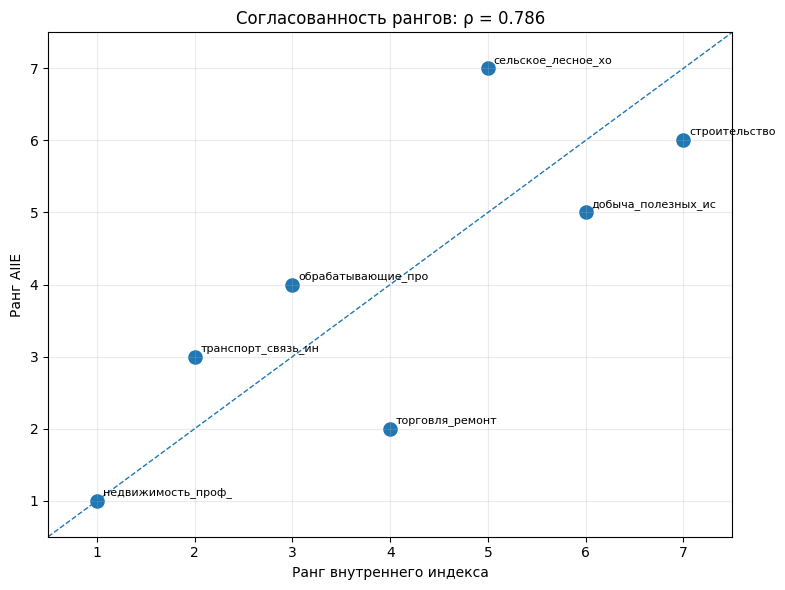

In [ ]:
external = pd.Series(AIIE_BY_SECTOR, name="AIIE_external").rename_axis("vrp_sector").reset_index()
validation = sector_exposure.merge(external, on="vrp_sector")

validation["rank_internal"] = validation["sector_AI_intensity"].rank(ascending=False)
validation["rank_external"] = validation["AIIE_external"].rank(ascending=False)

rho, p = spearmanr(validation["sector_AI_intensity"], validation["AIIE_external"])
print(f"Spearman ρ = {rho:.3f}, p = {p:.4f}, n = {len(validation)}")

cols = [
    "sector_name", "sector_AI_intensity", "AIIE_external",
    "rank_internal", "rank_external", "n_okved",
    "n_complete_okved", "mean_data_quality"
]
display(validation[cols].sort_values("rank_internal").reset_index(drop=True).round(3))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(validation["rank_internal"], validation["rank_external"], s=90)

for row in validation.itertuples():
    ax.annotate(
        row.vrp_sector[:18],
        (row.rank_internal, row.rank_external),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

limit = len(validation) + 0.5
ax.plot([0.5, limit], [0.5, limit], linestyle="--", linewidth=1)
ax.set(
    xlim=(0.5, limit),
    ylim=(0.5, limit),
    xlabel="Ранг внутреннего индекса",
    ylabel="Ранг AIIE",
    title=f"Согласованность рангов: ρ = {rho:.3f}"
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_внешняя_проверка.png", dpi=200, bbox_inches="tight")
plt.show()

## 9. Итоговые отраслевые таблицы и рекомендации

Основной рейтинг включает только отрасли с полным временным рядом. Неполные отрасли выводятся отдельно как предварительные оценки.

In [ ]:
components = {
    "skvoz_score": "Сквозные технологии",
    "training_score": "Обучение работников"
}

component_cols = list(components)

profile["lowest_component"] = profile[component_cols].idxmin(axis=1).map(components)
profile["lowest_component_score"] = profile[component_cols].min(axis=1)

profile["component_status"] = np.select(
    [
        profile["lowest_component_score"] < 40,
        profile["lowest_component_score"] < 60
    ],
    [
        "Приоритетное ограничение",
        "Зона внимания"
    ],
    default="Удовлетворительный уровень"
)

actions = {
    "Сквозные технологии": "Расширить применение аналитики данных, автоматизации и решений ИИ.",
    "Обучение работников": "Развивать обучение и компетенции работы с данными и ИИ."
}

profile["recommendation"] = profile["lowest_component"].map(actions)

result_cols = [
    "rank", "okved2", "sector", "AI_intensity",
    "lowest_component", "lowest_component_score",
    "component_status", "recommendation"
]

main_results = profile[profile["complete_panel"]][result_cols].sort_values("rank")
preliminary_results = profile[~profile["complete_panel"]][
    ["okved2", "sector", "AI_intensity", "years_count", "available_years",
     "lowest_component", "component_status", "recommendation"]
].sort_values("AI_intensity", ascending=False)

print("Основной рейтинг")
display(main_results.reset_index(drop=True).round(2))

print("Предварительные оценки")
display(preliminary_results.reset_index(drop=True).round(2))

Основной рейтинг


,rank,okved2,sector,AI_intensity,lowest_component,lowest_component_score,component_status,recommendation
0,1,72,Научные исследования и разработки,96.43,Сквозные технологии,96.43,Удовлетворительный уровень,"Расширить применение аналитики данных, автомат..."
1,2,26,"Производство компьютеров, электронных и оптиче...",89.29,Сквозные технологии,89.29,Удовлетворительный уровень,"Расширить применение аналитики данных, автомат..."
2,2,71,Деятельность в области архитектуры и инженерно...,89.29,Сквозные технологии,85.71,Удовлетворительный уровень,"Расширить применение аналитики данных, автомат..."
3,4,25,"Производство готовых металлических изделий, кр...",82.14,Обучение работников,71.43,Удовлетворительный уровень,Развивать обучение и компетенции работы с данн...
4,5,28,"Производство машин и оборудования, не включенн...",78.57,Сквозные технологии,75.00,Удовлетворительный уровень,"Расширить применение аналитики данных, автомат..."
5,6,30,Производство прочих транспортных средств и обо...,73.21,Сквозные технологии,60.71,Удовлетворительный уровень,"Расширить применение аналитики данных, автомат..."
6,7,49,Деятельность сухопутного и трубопроводного тра...,66.07,Обучение работников,64.29,Удовлетворительный уровень,Развивать обучение и компетенции работы с данн...
7,8,27,Производство электрического оборудования,66.07,Сквозные технологии,53.57,Зона внимания,"Расширить применение аналитики данных, автомат..."
8,9,73,Деятельность рекламная и исследование конъюнкт...,60.71,Сквозные технологии,46.43,Зона внимания,"Расширить применение аналитики данных, автомат..."
9,9,19,Производство кокса и нефтепродуктов,60.71,Обучение работников,21.43,Приоритетное ограничение,Развивать обучение и компетенции работы с данн...


Предварительные оценки


,okved2,sector,AI_intensity,years_count,available_years,lowest_component,component_status,recommendation
0,51,Деятельность воздушного и космического транспорта,56.01,1,2023,Сквозные технологии,Приоритетное ограничение,"Расширить применение аналитики данных, автомат..."
1,17,Производство бумаги и бумажных изделий,51.38,2,"2021, 2024",Сквозные технологии,Зона внимания,"Расширить применение аналитики данных, автомат..."
2,08,Добыча прочих полезных ископаемых,50.00,2,"2021, 2024",Сквозные технологии,Приоритетное ограничение,"Расширить применение аналитики данных, автомат..."
3,77,Аренда и лизинг,47.12,3,"2021, 2022, 2024",Сквозные технологии,Приоритетное ограничение,"Расширить применение аналитики данных, автомат..."
4,18,Деятельность полиграфическая и копирование нос...,44.86,3,"2021, 2022, 2023",Сквозные технологии,Приоритетное ограничение,"Расширить применение аналитики данных, автомат..."
5,50,Деятельность водного транспорта,30.41,2,"2021, 2022",Сквозные технологии,Приоритетное ограничение,"Расширить применение аналитики данных, автомат..."
6,05,Добыча угля,10.88,2,"2021, 2022",Обучение работников,Приоритетное ограничение,Развивать обучение и компетенции работы с данн...
7,41,Строительство зданий,10.32,3,"2021, 2022, 2023",Обучение работников,Приоритетное ограничение,Развивать обучение и компетенции работы с данн...
8,53,Деятельность почтовой связи и курьерская деяте...,10.26,1,2021,Обучение работников,Приоритетное ограничение,Развивать обучение и компетенции работы с данн...
9,42,Строительство инженерных сооружений,6.79,3,"2021, 2022, 2023",Обучение работников,Приоритетное ограничение,Развивать обучение и компетенции работы с данн...


## 10. Экспорт результатов отраслевого анализа

В этой ячейке сохраняются полный Excel-файл, основные CSV-таблицы и все графики, созданные выше.

In [ ]:
output_file = SECTOR_RESULTS_DIR / "Результаты_отраслевого_анализа.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    coverage.to_excel(writer, sheet_name="Полнота данных", index=False)
    profile.to_excel(writer, sheet_name="Отраслевой профиль", index=False)
    main_results.to_excel(writer, sheet_name="Основной рейтинг", index=False)
    preliminary_results.to_excel(writer, sheet_name="Неполные отрасли", index=False)
    sector_exposure.to_excel(writer, sheet_name="Семь секторов", index=False)

sector_exposure.to_csv(
    TABLES_DIR / "AI_интенсивность_семи_секторов.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Результаты сохранены:", output_file)

Результаты сохранены: /content/Результаты_отраслевого_анализа/Результаты_отраслевого_анализа.xlsx


## 11. Экспорт входных данных для регионального анализа


In [ ]:
REGIONAL_INPUT_XLSX = Path("/content/Входные_данные_для_регионального_анализа.xlsx")
REGIONAL_INPUT_CSV = Path("/content/AI_интенсивность_7_секторов.csv")

regional_sector_input = sector_exposure[[
    "vrp_sector", "sector_name", "sector_AI_intensity",
    "n_okved", "n_complete_okved", "mean_data_quality"
]].sort_values("vrp_sector").reset_index(drop=True)

industry_mapping_input = profile[[
    "okved2", "sector", "vrp_sector", "AI_intensity",
    "complete_panel", "years_count", "available_years",
    "data_quality_weight", "VDS_mean"
]].copy()

if len(regional_sector_input) != 7:
    raise ValueError("Должно быть семь укрупнённых секторов.")

if regional_sector_input["vrp_sector"].duplicated().any():
    raise ValueError("Есть повторяющиеся сектора.")

if regional_sector_input["sector_AI_intensity"].isna().any():
    raise ValueError("Есть пропуски в AI-интенсивности.")

with pd.ExcelWriter(REGIONAL_INPUT_XLSX, engine="openpyxl") as writer:
    regional_sector_input.to_excel(writer, sheet_name="7 секторов", index=False)
    industry_mapping_input.to_excel(writer, sheet_name="Соответствие ОКВЭД", index=False)

regional_sector_input.to_csv(REGIONAL_INPUT_CSV, index=False, encoding="utf-8-sig")

print("Файл сохранён:", REGIONAL_INPUT_XLSX)
display(regional_sector_input)

Файл сохранён: /content/Входные_данные_для_регионального_анализа.xlsx


,vrp_sector,sector_name,sector_AI_intensity,n_okved,n_complete_okved,mean_data_quality
0,добыча_полезных_ископаемых,Добыча полезных ископаемых,8.479526,5,3,0.800000
1,недвижимость_проф_научные_и_адм_услуги,"Профессиональные, научные и административные у...",78.735694,5,4,0.950000
2,обрабатывающие_производства,Обрабатывающие производства,58.202536,16,14,0.953125
3,сельское_лесное_хозяйство_рыболовство,"Сельское и лесное хозяйство, рыболовство",10.238683,3,3,1.000000
4,строительство,Строительство,8.151159,3,0,0.750000
5,торговля_ремонт,Торговля и ремонт,37.681860,3,3,1.000000
6,транспорт_связь_информация,"Транспорт, связь и информация",59.058442,5,2,0.600000


## Итог отраслевого блока

Главный результат - индекс отраслевой восприимчивости и агрегированная экспозиция семи укрупнённых секторов. Эти значения далее объединяются со структурой ВРП регионов.